# 05 — Logistics Cost Benchmarking
### Branch 4 of the MECE issue tree: the testable parts only

**Hypotheses under test**

| ID | Hypothesis |
|---|---|
| H4.1 | Last-mile delivery cost is a large share of per-order logistics cost, and structurally cheaper where catchments are dense |
| H4.2 | Tier-2 expansion raises blended delivery cost due to weaker density/rider-pool economics |
| H4.3 | The marketplace model prevents Instamart from optimizing replenishment/fill rates as tightly as Blinkit's inventory model |
| H4.4 | Rising rider compensation and gig-worker regulation will inflate costs going forward |

**This notebook is deliberately short.** Branch 4 has the thinnest public data of any
branch in this case study — only one company (Blinkit) discloses a delivery-cost figure
at all, and even that is two data points. Building this out to the same length as the
other branch notebooks would mean padding with manufactured charts the data doesn't
support. H4.2 and H4.4 stay qualitative below because that's an accurate reflection of
what's publicly knowable, not a gap in the analysis.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

candidates = [Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\processed"), Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\preprocessed")]
PROCESSED = next((p for p in candidates if p.exists()), candidates[0])
print(f"Using data directory: {PROCESSED.resolve()}")

master = pd.read_csv(PROCESSED / "master_metrics.csv")
print(f"Loaded {len(master)} rows from master_metrics.csv")


Using data directory: D:\Downloads\swiggy-instamart-casestudy\data\processed
Loaded 99 rows from master_metrics.csv


## H4.1 — Delivery cost per order: the only disclosed figure across all three players

Blinkit discloses ₹55 per order in Q4 FY25, down 14% YoY — implying a Q4 FY24 figure
around ₹64. Neither Instamart nor Zepto discloses a comparable figure at all.


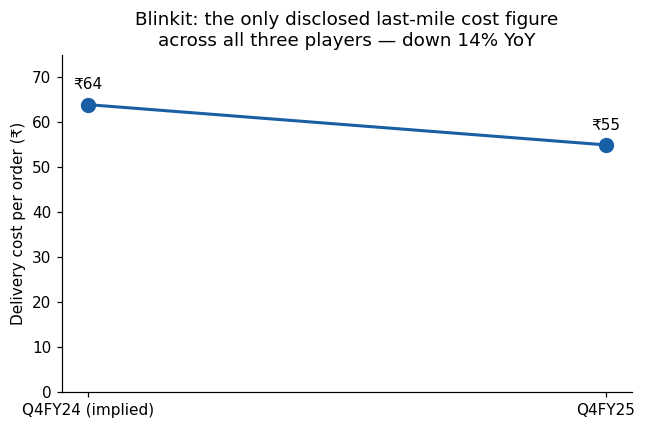

In [2]:

delivery_cost = master[master.metric == "Delivery Cost per Order"].copy()
q4fy25_cost = delivery_cost["value"].iloc[0]
yoy_pct = delivery_cost["yoy_pct"].iloc[0]
q4fy24_implied = q4fy25_cost / (1 + yoy_pct / 100)

trend = pd.DataFrame({
    "period": ["Q4FY24 (implied)", "Q4FY25"],
    "cost": [q4fy24_implied, q4fy25_cost],
})

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(trend["period"], trend["cost"], marker="o", color="#185FA5", linewidth=2, markersize=9)
for x, y in zip(trend["period"], trend["cost"]):
    ax.annotate(f"₹{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)
ax.set_ylabel("Delivery cost per order (₹)")
ax.set_ylim(0, 75)
ax.set_title("Blinkit: the only disclosed last-mile cost figure\nacross all three players \u2014 down 14% YoY")
plt.tight_layout()
plt.savefig(PROCESSED / "b4_chart_delivery_cost_trend.png", bbox_inches="tight")
plt.show()


**Verdict on H4.1:** Directionally supported but resting on a single company's
two-point series. The 14% YoY improvement is consistent with density-driven delivery-cost
leverage (more orders per route, better rider utilization), which lines up with Blinkit's
density advantage established in Notebook 02. But "structurally cheaper where catchments
are dense" can't be tested across players here — there's no Instamart or Zepto figure to
compare it to. If Swiggy ever discloses an equivalent figure, this is the first chart in
the case study that should get updated.


## H4.3 — The inventory-model margin opportunity, and the FDI rule that blocks it

This isn't a logistics-cost figure in the delivery sense, but it's the most quantified
part of Branch 4 — and it's a **regulatory/ownership** story (India's FDI rules), not just
an operating one.

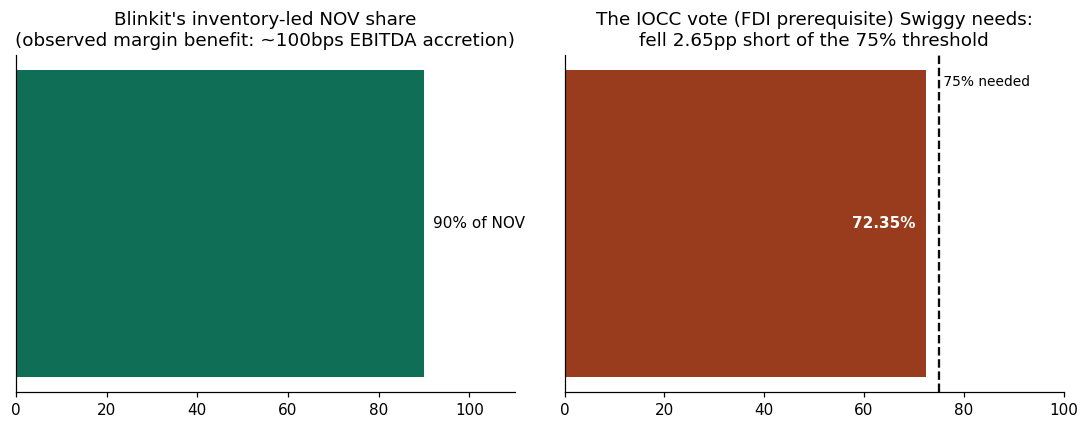

In [3]:
inventory_share = master.loc[master.metric == "Inventory-led NOV Share", "value"].iloc[0]
# Real-data note: the inventory benefit is Blinkit's OBSERVED ~100bps EBITDA accretion (Eternal CFO,
# Q2FY26), the proxy for what Instamart could gain. The block is REGULATORY: India's FDI rules bar
# foreign-funded firms from the inventory-led model, so the entity must first become Indian-Owned-and-
# Controlled (IOCC) — the special resolution to enable that failed at 72.35% vs 75% (Swiggy never transitioned).
margin_benefit_bps = master.loc[master.metric == "Inventory Model Margin Benefit (EBITDA accretion)", "value"].iloc[0]
vote_share = master.loc[master.metric == "IOCC Resolution Vote Share", "value"].iloc[0]
THRESHOLD_NEEDED = 75.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].barh(["Blinkit"], [inventory_share], color="#0F6E56")
axes[0].text(inventory_share + 2, 0, f"{inventory_share:.0f}% of NOV", va="center", fontsize=10)
axes[0].set_xlim(0, 110)
axes[0].set_title(f"Blinkit's inventory-led NOV share\n(observed margin benefit: ~{margin_benefit_bps:.0f}bps EBITDA accretion)")
axes[0].set_yticks([])

axes[1].barh(["IOCC vote"], [vote_share], color="#993C1D")
axes[1].axvline(THRESHOLD_NEEDED, color="#0C0C0C", linestyle="--", linewidth=1.5)
axes[1].text(THRESHOLD_NEEDED, 0.35, f" {THRESHOLD_NEEDED:.0f}% needed", fontsize=9, va="bottom")
axes[1].text(vote_share - 2, 0, f"{vote_share:.2f}%", va="center", ha="right", fontsize=10, color="white", fontweight="bold")
axes[1].set_xlim(0, 100)
axes[1].set_title(f"The IOCC vote (FDI prerequisite) Swiggy needs:\nfell {THRESHOLD_NEEDED - vote_share:.2f}pp short of the 75% threshold")
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(PROCESSED / "b4_chart_inventory_model_opportunity.png", bbox_inches="tight")
plt.show()

**Verdict on H4.3:** Supported. Blinkit gets roughly a **~100bps EBITDA accretion (plus ~300bps of
gross-margin lift)** from running 90% of its volume through an owned-inventory model — the figure comes
from Eternal's CFO (Q2 FY26 call) and is **Blinkit's observed benefit, used here as the proxy for what
Instamart could gain.** But the block on Instamart copying it is **regulatory, not economic**: India's
FDI rules bar foreign-funded firms from the inventory-led model (only the marketplace model is open to
100% FDI), so Instamart's operating entity must first become **Indian-Owned-and-Controlled (IOCC)**.
Swiggy's special resolution to enable that **failed at 72.35% vs the 75% needed** — foreign shareholders
balked at the ownership/control change. Blinkit can run inventory-led *only* because Eternal restructured
to IOCC. So this is a multi-quarter ownership/restructuring question (Branch 6 territory), not a margin
debate. And keep the size in perspective: the strategy simulations (06a/06d) rate this lever **secondary
to density** (~100bps vs several percentage points) — a real but second-order, *regulation-gated* fix,
not *the* unlock the headline framing implies.

## H4.2 — Tier-2 cost inflation (qualitative only)

Bernstein's commentary (cited in the issue-tree research) argues tier-2 expansion raises
blended delivery cost due to weaker rider-pool density and lower order concentration per
route. No public figure breaks out delivery cost by city tier for any of the three
players. **Verdict: not independently testable with available public data.** This stays
a qualitative risk flag rather than a charted finding — testing it properly would need
city-tier-level cost disclosure that doesn't exist publicly.

## H4.4 — Rider compensation and gig-worker regulation (qualitative only)

This is a forward-looking policy risk (gig-worker classification rules, minimum-wage-style
proposals for platform riders) rather than a backward-looking metric, so there is nothing
to chart by construction — the hypothesis is about a *future* cost, not a *current* one.
**Verdict: not testable retrospectively; worth carrying forward as a risk factor in the
strategy recommendation rather than a tested finding.**


## Branch 4 summary

In [4]:
verdict = pd.DataFrame([
    dict(hypothesis_id="H4.1", hypothesis="Last-mile cost is large and density-sensitive",
         verdict="Directionally supported (single company, 2 points)", evidence="Blinkit ₹55/order, -14% YoY; no Instamart/Zepto comparator exists"),
    dict(hypothesis_id="H4.2", hypothesis="Tier-2 expansion raises blended delivery cost",
         verdict="Not independently testable", evidence="No public city-tier cost breakdown for any player"),
    dict(hypothesis_id="H4.3", hypothesis="Marketplace model prevents Instamart from matching Blinkit's replenishment efficiency",
         verdict="Supported (regulation-gated, secondary lever)", evidence="Blocked for Instamart by FDI rules (needs IOCC); enabling vote fell 2.65pp short of 75%. 90% Blinkit inventory-led NOV, ~100bps EBITDA. Secondary to density (06a/06d)"),
    dict(hypothesis_id="H4.4", hypothesis="Rider/regulatory cost inflation is a forward risk",
         verdict="Not testable retrospectively", evidence="Forward-looking policy risk by construction, not a backward-looking metric"),
])
verdict.to_csv(PROCESSED / "b4_verdict_summary.csv", index=False)
verdict

,hypothesis_id,hypothesis,verdict,evidence
0,H4.1,Last-mile cost is large and density-sensitive,"Directionally supported (single company, 2 points)","Blinkit ₹55/order, -14% YoY; no Instamart/Zepto comparator exists"
1,H4.2,Tier-2 expansion raises blended delivery cost,Not independently testable,No public city-tier cost breakdown for any player
2,H4.3,Marketplace model prevents Instamart from matching Blinkit's replenishment efficiency,"Supported (regulation-gated, secondary lever)",Blocked for Instamart by FDI rules (needs IOCC); enabling vote fell 2.65pp short of 75...
3,H4.4,Rider/regulatory cost inflation is a forward risk,Not testable retrospectively,"Forward-looking policy risk by construction, not a backward-looking metric"
